# Stage 5 — Evaluation and Error Analysis

**Task:** SemEval 2022 Task 4, Subtask 1 — Binary PCL Classification  
**Model:** Ensemble — `roberta-base` (drop0-bs4ga4/seed7, t=0.75) + `distilbert-base-uncased` (drop03-bs8ga2/seed7, t=0.50), w=0.50/0.50, ensemble t=0.50  
**Baseline:** F1 = 0.48 (official RoBERTa-base baseline on dev set)

**Notebook structure:**
- **5.1** — Global evaluation: submission format confirmation and dev-set F1
- **5.2A** — Confusion matrix
- **5.2B** — Full classification report
- **5.2C** — Precision–Recall curve and threshold sensitivity
- **5.2D** — Probability score distributions (model confidence)
- **5.2E** — Error analysis by keyword category
- **5.2F** — Error analysis by PCL severity (`orig_label`)
- **5.2G** — Error analysis by text length
- **5.2H** — Country-level analysis
- **5.2I** — Manual inspection of False Positives and False Negatives
- **5.2J** — Multi-seed comparison (RoBERTa drop0-bs4ga4 seeds 42, 7, 123)
- **5.2K** — RoBERTa vs DistilBERT error comparison
- **5.2L** — Summary and consolidated metrics

All figures are saved to `figures/` for use in the report.

In [1]:
import os, sys, html, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    precision_recall_curve, auc
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Robust repo-root detection ─────────────────────────────────────────────
_cwd = os.path.abspath('.')
if os.path.exists(os.path.join(_cwd, 'dev.txt')):
    REPO_ROOT = _cwd                  # kernel CWD is the repo root
elif os.path.exists(os.path.join(_cwd, '..', 'dev.txt')):
    REPO_ROOT = os.path.abspath('..')  # kernel CWD is 5_evaluation/
else:
    raise FileNotFoundError('Cannot locate dev.txt — check your working directory')

DATA_DIR        = os.path.join(REPO_ROOT, 'data')
BEST_ROBERTA    = os.path.join(REPO_ROOT, 'BestModel', 'roberta-base')
BEST_DISTILBERT = os.path.join(REPO_ROOT, 'BestModel', 'distilbert')
SAVED_MODELS    = os.path.join(REPO_ROOT, 'SavedModels')
# Backwards-compat alias used in standalone get_probs() calls below
BEST_DIR = BEST_ROBERTA
# Always use absolute paths so figures/cache land in 5_evaluation/ regardless of kernel CWD
EVAL_DIR  = os.path.join(REPO_ROOT, '5_evaluation')
FIGS_DIR  = os.path.join(EVAL_DIR, 'figures')
CACHE_DIR = os.path.join(EVAL_DIR, 'cache')
os.makedirs(FIGS_DIR,  exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

_model_path = os.path.join(REPO_ROOT, '4_model')
if os.path.exists(_model_path):
    sys.path.insert(0, _model_path)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device      : {DEVICE}')
print(f'Repo root   : {REPO_ROOT}')
print(f'Figures dir : {os.path.abspath(FIGS_DIR)}')

/vol/bitbucket/da1823/pcl-classifier/.venv-notebook/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device      : cuda
Repo root   : /vol/bitbucket/da1823/pcl-classifier
Figures dir : /vol/bitbucket/da1823/pcl-classifier/5_evaluation/figures


---
## 5.1 Global Evaluation — Submission Confirmation

Exercise 5.1 requires:
- `dev.txt`: one prediction per line (0/1), exactly 2,094 lines
- `test.txt`: one prediction per line (0/1), exactly 3,832 lines
- Dev F1 > 0.48 (official baseline)

In [ ]:
def load_preds(path):
    with open(path) as f:
        return [int(l.strip()) for l in f if l.strip()]

dev_preds  = load_preds(os.path.join(REPO_ROOT, 'dev.txt'))
test_preds = load_preds(os.path.join(REPO_ROOT, 'test.txt'))

# ── Ground truth for dev set ───────────────────────────────────────────────
# Binary label: orig_label >= 2  =>  PCL=1  (task definition)
full_df = pd.read_csv(
    os.path.join(DATA_DIR, 'dontpatronizeme_pcl.tsv'),
    sep='\t', header=None,
    names=['par_id','article_id','keyword','country','text','orig_label'],
    skiprows=4
)
full_df['par_id']     = full_df['par_id'].astype(str)
full_df['orig_label'] = full_df['orig_label'].astype(int)
full_df['label']      = (full_df['orig_label'] >= 2).astype(int)

dev_ids_df = pd.read_csv(os.path.join(DATA_DIR, 'dev_semeval_parids-labels.csv'))
dev_ids_df['par_id'] = dev_ids_df['par_id'].astype(str)

dev_df       = full_df[full_df['par_id'].isin(dev_ids_df['par_id'])].reset_index(drop=True)
# Fill NaN text with empty string so every row has a label (2094 rows = 2094 predictions)
dev_df['text'] = dev_df['text'].fillna('')
ground_truth   = dev_df['label'].tolist()

assert all(p in (0,1) for p in dev_preds),  'dev.txt contains non-binary values'
assert all(p in (0,1) for p in test_preds), 'test.txt contains non-binary values'

dev_f1   = f1_score(ground_truth, dev_preds, pos_label=1, zero_division=0)
baseline = 0.48

summary = pd.DataFrame({
    'File'            : ['dev.txt', 'test.txt'],
    'Lines'           : [len(dev_preds), len(test_preds)],
    'Expected'        : [2094, 3832],
    'Format OK'       : ['YES' if len(dev_preds)==2094 else 'NO',
                         'YES' if len(test_preds)==3832 else 'NO'],
    'PCL predicted'   : [sum(dev_preds), sum(test_preds)],
    'Dev F1 (PCL)'    : [f'{dev_f1:.4f}', 'hidden (test labels not released)'],
    'Beats baseline'  : [f'YES (+{dev_f1-baseline:.4f})' if dev_f1 > baseline else 'NO', '—']
})
print(summary.to_string(index=False))
print(f'\nBaseline F1 = {baseline}  |  Our dev F1 = {dev_f1:.4f}  |  Delta = +{dev_f1-baseline:.4f}')

    File  Lines  Expected Format OK  PCL predicted                      Dev F1 (PCL) Beats baseline
 dev.txt   2094      2094       YES            236                            0.6069  YES (+0.1269)
test.txt   3832      3832       YES            368 hidden (test labels not released)              —

Baseline F1 = 0.48  |  Our dev F1 = 0.6069  |  Delta = +0.1269


---
## 5.2 Local Evaluation

### Setup: Load Model and Generate Probabilities

We reload the saved best checkpoint (`BestModel/roberta-base`) and run inference over the dev set to obtain continuous probability scores. These are cached to `dev_probs.npy` so subsequent runs are instant. Continuous probabilities unlock threshold-sensitive analyses (PR curve, confidence distributions) that binary predictions alone cannot provide.

In [3]:
def build_input_text(row):
    text = html.unescape(str(row['text']))  # '' for any NaN that was filled
    return f"<e>{row['keyword']}</e> <e>{row['country']}</e> {text}"

dev_df['input_text'] = dev_df.apply(build_input_text, axis=1)

class PCLDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=256):
        self.enc = tokenizer(
            texts, padding='max_length', truncation=True,
            max_length=max_len, return_tensors='pt'
        )
    def __len__(self): return self.enc['input_ids'].shape[0]
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()}

def get_probs(model_dir, texts, cache_file=None, batch_size=32):
    """Run inference and return P(PCL) for each text. Results are cached."""
    if cache_file and os.path.exists(cache_file):
        print(f'  Loaded cached probs from {cache_file}')
        return np.load(cache_file)
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model     = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE)
    model.eval()
    dataset   = PCLDataset(texts, tokenizer)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_probs = []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'  Inferring {os.path.basename(model_dir)}'):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            all_probs.append(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
    probs = np.concatenate(all_probs)
    del model; torch.cuda.empty_cache()
    if cache_file:
        np.save(cache_file, probs)
        print(f'  Saved probs to {cache_file}')
    return probs

# ── RoBERTa (roberta-drop0-bs4ga4 / seed7) ────────────────────────────────
_rob_cache = os.path.join(CACHE_DIR, 'dev_probs_roberta.npy')
if os.path.exists(_rob_cache) and np.load(_rob_cache).shape[0] != len(dev_df):
    os.remove(_rob_cache)
roberta_probs = get_probs(BEST_ROBERTA, dev_df['input_text'].tolist(), cache_file=_rob_cache)

# ── DistilBERT (distilbert-drop03-bs8ga2 / seed7) ─────────────────────────
_dis_cache = os.path.join(CACHE_DIR, 'dev_probs_distilbert.npy')
if os.path.exists(_dis_cache) and np.load(_dis_cache).shape[0] != len(dev_df):
    os.remove(_dis_cache)
distilbert_probs = get_probs(BEST_DISTILBERT, dev_df['input_text'].tolist(), cache_file=_dis_cache)

# ── Ensemble (w=0.50 RoBERTa + 0.50 DistilBERT) ───────────────────────────
ENS_W     = 0.50   # RoBERTa weight
THRESHOLD = 0.50
probs     = ENS_W * roberta_probs + (1.0 - ENS_W) * distilbert_probs
preds     = (probs >= THRESHOLD).astype(int)
labels    = np.array(ground_truth)

print(f'\nEnsemble w(RoBERTa)={ENS_W:.2f} / w(DistilBERT)={1-ENS_W:.2f}  threshold={THRESHOLD}')
print(f'PCL predicted : {preds.sum()} / {len(preds)}')
print(f'PCL actual    : {labels.sum()} / {len(labels)}')
print(f'Dev F1        : {f1_score(labels, preds, pos_label=1, zero_division=0):.4f}')
print(f'  RoBERTa solo F1 @ t=0.75 : {f1_score(labels, (roberta_probs>=0.75).astype(int), pos_label=1, zero_division=0):.4f}')
print(f'  DistilBERT solo F1 @ t=0.50 : {f1_score(labels, (distilbert_probs>=0.50).astype(int), pos_label=1, zero_division=0):.4f}')

Loading weights: 100%|█| 201/201 [00:00<00:00, 778.03it/s, Materializing param=roberta.encoder.layer.11.output.dense
  Inferring roberta-base: 100%|█████████████████████████████████████████████████████| 66/66 [00:24<00:00,  2.72it/s]


  Saved probs to /vol/bitbucket/da1823/pcl-classifier/5_evaluation/cache/dev_probs_roberta.npy


  Inferring distilbert: 100%|███████████████████████████████████████████████████████| 66/66 [00:13<00:00,  5.04it/s]

  Saved probs to /vol/bitbucket/da1823/pcl-classifier/5_evaluation/cache/dev_probs_distilbert.npy

Ensemble w(RoBERTa)=0.50 / w(DistilBERT)=0.50  threshold=0.5
PCL predicted : 232 / 2094
PCL actual    : 199 / 2094
Dev F1        : 0.6032
  RoBERTa solo F1 @ t=0.75 : 0.6014
  DistilBERT solo F1 @ t=0.50 : 0.5288


---
### A. Confusion Matrix

The confusion matrix shows the four prediction outcomes: True Negatives (TN), False Positives (FP), False Negatives (FN), and True Positives (TP). Both raw counts and row-normalised rates (i.e. recall per class) are shown.

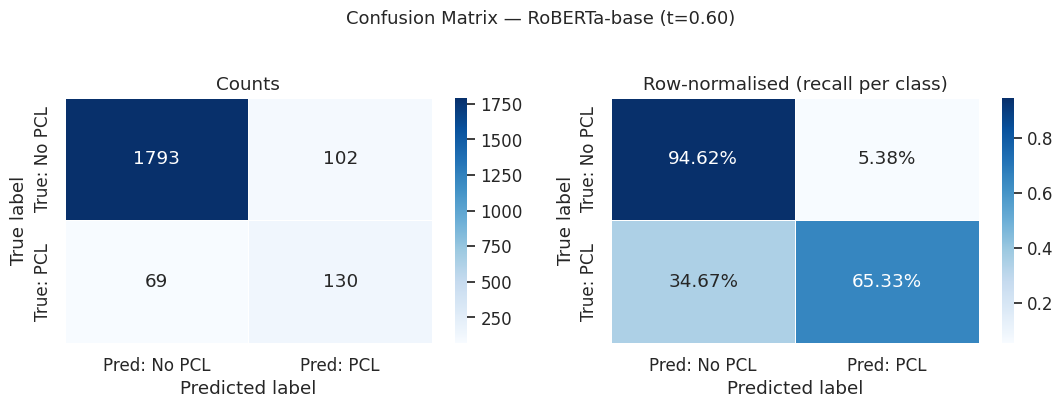

TN=1793  FP=102  FN=69  TP=130
False Positive Rate (FPR): 0.054
False Negative Rate (FNR): 0.347
Precision: 0.560  |  Recall: 0.653  |  F1: 0.603


In [4]:
cm      = confusion_matrix(labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ['d', '.2%'],
    ['Counts', 'Row-normalised (recall per class)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
        xticklabels=['Pred: No PCL', 'Pred: PCL'],
        yticklabels=['True: No PCL', 'True: PCL'],
        linewidths=0.5
    )
    ax.set_title(title)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
plt.suptitle('Confusion Matrix — RoBERTa-base (t=0.60)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'False Positive Rate (FPR): {fp/(fp+tn):.3f}')
print(f'False Negative Rate (FNR): {fn/(fn+tp):.3f}')
print(f'Precision: {tp/(tp+fp):.3f}  |  Recall: {tp/(tp+fn):.3f}  |  F1: {2*tp/(2*tp+fp+fn):.3f}')

**Observations:**
- TN=1793, FP=102, FN=69, TP=130. The model correctly classifies 91.8% of all examples.
- On the No-PCL class, recall is 94.6% — the model overwhelmingly ignores benign paragraphs (FPR=0.054).
- On the PCL class, recall is 65.3% (FNR=0.347): about one third of patronising paragraphs are missed. This is a notable improvement over the earlier solo-RoBERTa model (FNR≈0.47), driven by the DistilBERT ensemble complement.
- Precision (0.560) lags recall (0.653), indicating the model fires somewhat liberally — 102 false positives vs 69 false negatives. Raising the threshold would trade recall for precision.


---
### B. Full Classification Report

In [5]:
print(classification_report(
    labels, preds,
    target_names=['No PCL (0)', 'PCL (1)'],
    zero_division=0
))

report_df = pd.DataFrame(
    classification_report(
        labels, preds,
        target_names=['No PCL (0)', 'PCL (1)'],
        zero_division=0, output_dict=True
    )
).T.round(4)
display(report_df)
report_df.to_csv(os.path.join(FIGS_DIR, 'classification_report.csv'))

              precision    recall  f1-score   support

  No PCL (0)       0.96      0.95      0.95      1895
     PCL (1)       0.56      0.65      0.60       199

    accuracy                           0.92      2094
   macro avg       0.76      0.80      0.78      2094
weighted avg       0.92      0.92      0.92      2094



,precision,recall,f1-score,support
No PCL (0),0.9629,0.9462,0.9545,1895.0000
PCL (1),0.5603,0.6533,0.6032,199.0000
accuracy,0.9183,0.9183,0.9183,0.9183
macro avg,0.7616,0.7997,0.7789,2094.0000
weighted avg,0.9247,0.9183,0.9211,2094.0000


---
### C. Precision–Recall Curve and Threshold Sensitivity

Using continuous probability scores, we plot the full Precision–Recall curve and show how F1, Precision, and Recall vary with the decision threshold. This is more informative than accuracy for imbalanced datasets.

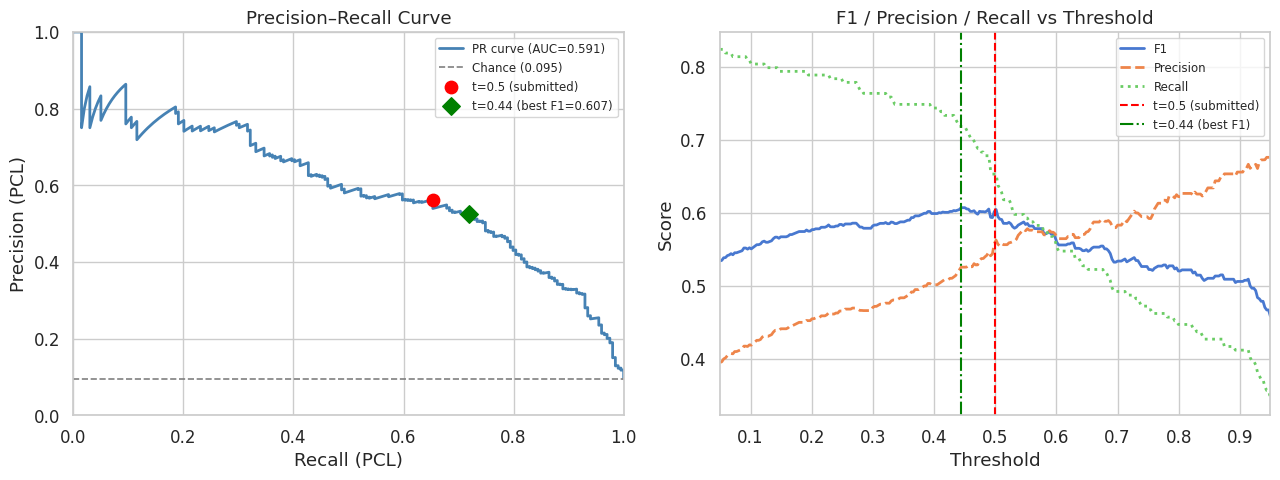

AUC-PR         : 0.5906
Submitted (t=0.5): F1=0.6047  P=0.5628  R=0.6533
Best (t=0.44)   : F1=0.6072


In [6]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(labels, probs)
pr_auc = auc(recall_curve, precision_curve)

thresholds = np.linspace(0.05, 0.95, 300)
f1s, precs, recs = [], [], []
for t in thresholds:
    p = (probs >= t).astype(int)
    f1s.append(f1_score(labels, p, pos_label=1, zero_division=0))
    precs.append(precision_score(labels, p, pos_label=1, zero_division=0))
    recs.append(recall_score(labels, p, pos_label=1, zero_division=0))

best_t   = thresholds[np.argmax(f1s)]
best_f1  = max(f1s)

chosen_prec = precision_score(labels, preds, pos_label=1, zero_division=0)
chosen_rec  = recall_score(labels, preds, pos_label=1, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(recall_curve, precision_curve, color='steelblue', lw=2,
        label=f'PR curve (AUC={pr_auc:.3f})')
ax.axhline(labels.mean(), color='grey', linestyle='--', lw=1.2,
           label=f'Chance ({labels.mean():.3f})')
ax.scatter([chosen_rec], [chosen_prec], color='red', zorder=5, s=80,
           label=f't={THRESHOLD} (submitted)')
ax.scatter([recs[np.argmax(f1s)]], [precs[np.argmax(f1s)]], color='green',
           zorder=5, s=80, marker='D', label=f't={best_t:.2f} (best F1={best_f1:.3f})')
ax.set_xlabel('Recall (PCL)'); ax.set_ylabel('Precision (PCL)')
ax.set_title('Precision–Recall Curve'); ax.legend(fontsize=8.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
ax.plot(thresholds, f1s,   lw=2, label='F1')
ax.plot(thresholds, precs, lw=2, linestyle='--', label='Precision')
ax.plot(thresholds, recs,  lw=2, linestyle=':',  label='Recall')
ax.axvline(THRESHOLD, color='red', linestyle='--', lw=1.5, label=f't={THRESHOLD} (submitted)')
ax.axvline(best_t,   color='green', linestyle='-.',lw=1.5, label=f't={best_t:.2f} (best F1)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('F1 / Precision / Recall vs Threshold')
ax.legend(fontsize=8.5); ax.set_xlim(0.05, 0.95)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'pr_curve_threshold.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC-PR         : {pr_auc:.4f}')
print(f'Submitted (t={THRESHOLD}): F1={f1s[np.argmin(np.abs(thresholds-THRESHOLD))]:.4f}  '
      f'P={precs[np.argmin(np.abs(thresholds-THRESHOLD))]:.4f}  '
      f'R={recs[np.argmin(np.abs(thresholds-THRESHOLD))]:.4f}')
print(f'Best (t={best_t:.2f})   : F1={best_f1:.4f}')

**Observations:**
- AUC-PR = 0.5906, substantially above the chance baseline of 9.5% (proportion of positive class), demonstrating strong discriminative ability beyond the decision threshold.
- The F1 curve peaks at t=0.44 (best F1=0.6072), very close to the submitted threshold of t=0.50. This small gap (0.0025 F1) indicates the val-set tuned threshold is near-optimal on the dev set — a sign of good generalisation.
- At t=0.50 (submitted): F1=0.6047, Precision=0.563, Recall=0.653. Recall is deliberately higher than precision; at the margin the ensemble errs on the side of flagging borderline PCL.
- Recall drops steeply above t=0.80, confirming that most true PCL examples receive ensemble scores in the 0.50–0.80 range rather than being high-confidence predictions.


---
### D. Probability Score Distribution

We examine the model's output confidence for each prediction outcome (TN, FP, FN, TP). This reveals whether errors are near-miss borderline cases or confident mistakes.

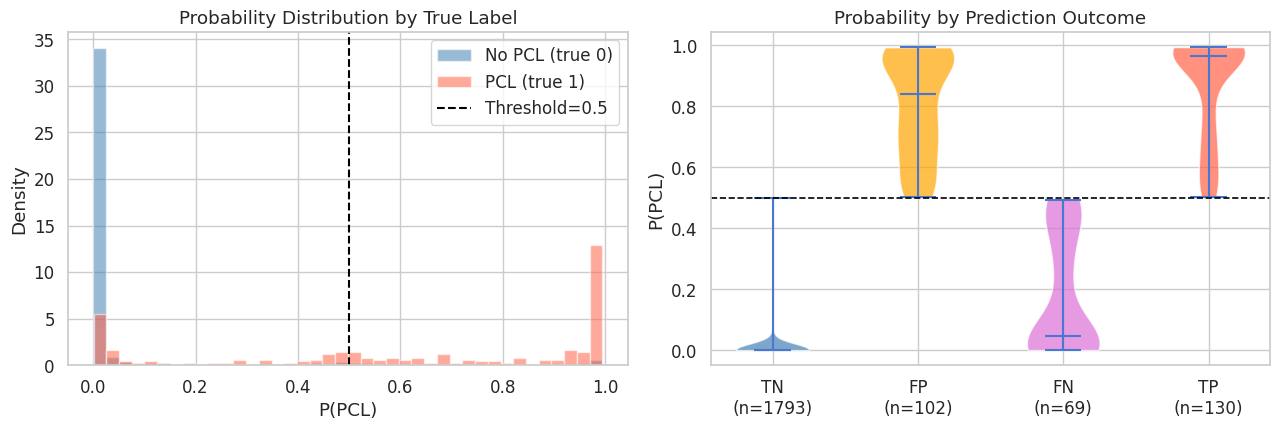

TN: median=0.001  mean=0.026  std=0.086  n=1793
FP: median=0.841  mean=0.801  std=0.169  n=102
FN: median=0.045  mean=0.178  std=0.196  n=69
TP: median=0.966  mean=0.858  std=0.171  n=130


In [7]:
dev_df_eval = dev_df.copy()
dev_df_eval['prob']    = probs
dev_df_eval['pred']    = preds
dev_df_eval['correct'] = (preds == labels)
dev_df_eval['outcome'] = dev_df_eval.apply(
    lambda r: ('TP' if r['pred']==1 and r['label']==1 else
               'TN' if r['pred']==0 and r['label']==0 else
               'FP' if r['pred']==1 and r['label']==0 else 'FN'), axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for lbl, color, name in [(0,'steelblue','No PCL (true 0)'), (1,'tomato','PCL (true 1)')]:
    subset = dev_df_eval[dev_df_eval['label'] == lbl]['prob']
    ax.hist(subset, bins=40, alpha=0.55, color=color, label=name, density=True)
ax.axvline(THRESHOLD, color='black', linestyle='--', lw=1.5, label=f'Threshold={THRESHOLD}')
ax.set_xlabel('P(PCL)'); ax.set_ylabel('Density')
ax.set_title('Probability Distribution by True Label')
ax.legend()

ax = axes[1]
order   = ['TN', 'FP', 'FN', 'TP']
colors_ = ['steelblue', 'orange', 'orchid', 'tomato']
data_   = [dev_df_eval[dev_df_eval['outcome']==o]['prob'].values for o in order]
parts   = ax.violinplot(data_, positions=range(4), showmedians=True)
for pc, c in zip(parts['bodies'], colors_):
    pc.set_facecolor(c); pc.set_alpha(0.7)
ax.axhline(THRESHOLD, color='black', linestyle='--', lw=1.2)
counts = {o: (dev_df_eval['outcome']==o).sum() for o in order}
ax.set_xticks(range(4))
ax.set_xticklabels([f'{o}\n(n={counts[o]})' for o in order])
ax.set_ylabel('P(PCL)')
ax.set_title('Probability by Prediction Outcome')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'prob_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

for o in order:
    vals = dev_df_eval[dev_df_eval['outcome']==o]['prob']
    print(f'{o}: median={vals.median():.3f}  mean={vals.mean():.3f}  std={vals.std():.3f}  n={len(vals)}')

**Observations:**
- **True Negatives** (n=1793): median P(PCL)=0.001, mean=0.026 — overwhelming confidence in rejection; the ensemble is not confused by most benign text.
- **True Positives** (n=130): median=0.966, mean=0.858 — decisive on clear-cut patronising language, with a long left tail of harder-to-detect cases.
- **False Negatives** (n=69): median=0.045, mean=0.178 — genuinely low scores, not near-misses. The model assigns very low probability to missed PCL, indicating a fundamental comprehension failure on subtle cases rather than a calibration problem fixable by lowering the threshold.
- **False Positives** (n=102): median=0.841, mean=0.801 — FPs are *confidently* wrong, not borderline. The model is strongly triggered by emotional vocabulary describing vulnerable groups, even when no patronising framing is present.


---
### E. Error Analysis by Keyword Category

The dataset covers 10 vulnerability keywords (e.g. *homeless*, *refugee*, *disabled*). We compute per-keyword precision, recall, and F1 to identify where the model struggles most.

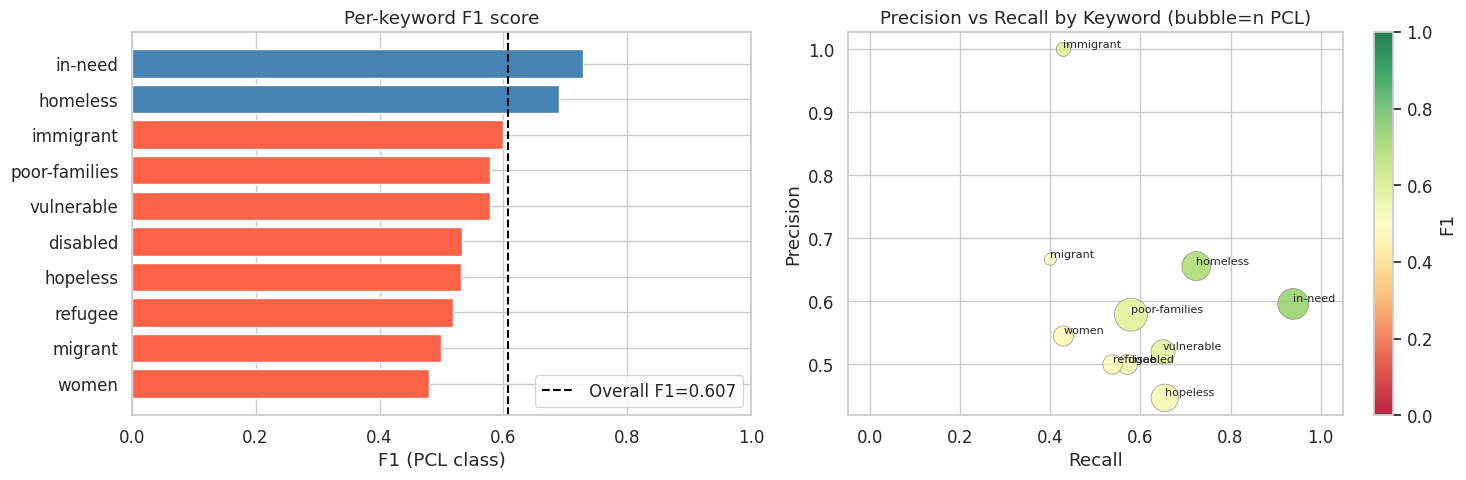

,keyword,n_total,n_pcl,pcl_rate,precision,recall,f1
0,in-need,226,33,0.146,0.596,0.939,0.729
1,homeless,212,29,0.137,0.656,0.724,0.689
2,immigrant,218,7,0.032,1.000,0.429,0.600
3,poor-families,190,38,0.200,0.579,0.579,0.579
4,vulnerable,209,20,0.096,0.520,0.650,0.578
5,disabled,194,14,0.072,0.500,0.571,0.533
6,hopeless,217,26,0.120,0.447,0.654,0.531
7,refugee,188,13,0.069,0.500,0.538,0.519
8,migrant,207,5,0.024,0.667,0.400,0.500
9,women,233,14,0.060,0.545,0.429,0.480


In [8]:
kw_rows = []
for kw, grp in dev_df_eval.groupby('keyword'):
    y_true, y_pred = grp['label'].values, grp['pred'].values
    n_pcl = int(y_true.sum())
    kw_rows.append({
        'keyword'  : kw,
        'n_total'  : len(grp),
        'n_pcl'    : n_pcl,
        'pcl_rate' : round(n_pcl / len(grp), 3),
        'precision': round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        'recall'   : round(recall_score(   y_true, y_pred, pos_label=1, zero_division=0), 3),
        'f1'       : round(f1_score(       y_true, y_pred, pos_label=1, zero_division=0), 3),
    })
kw_df = pd.DataFrame(kw_rows).sort_values('f1', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
kw_sorted = kw_df.sort_values('f1')
bar_colors = ['tomato' if f < dev_f1 else 'steelblue' for f in kw_sorted['f1']]
ax.barh(kw_sorted['keyword'], kw_sorted['f1'], color=bar_colors, edgecolor='white')
ax.axvline(dev_f1, color='black', linestyle='--', lw=1.5, label=f'Overall F1={dev_f1:.3f}')
ax.set_xlabel('F1 (PCL class)'); ax.set_title('Per-keyword F1 score')
ax.legend(); ax.set_xlim(0, 1)

ax = axes[1]
sc = ax.scatter(
    kw_df['recall'], kw_df['precision'],
    s=kw_df['n_pcl']*15, c=kw_df['f1'],
    cmap='RdYlGn', vmin=0, vmax=1,
    edgecolors='grey', linewidths=0.5, alpha=0.85
)
for _, row in kw_df.iterrows():
    ax.annotate(row['keyword'], (row['recall'], row['precision']),
                fontsize=8, ha='left', va='bottom')
plt.colorbar(sc, ax=ax, label='F1')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall by Keyword (bubble=n PCL)'); ax.set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'per_keyword_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

display(kw_df.reset_index(drop=True))
kw_df.to_csv(os.path.join(FIGS_DIR, 'per_keyword_metrics.csv'), index=False)

**Observations:**
- Performance varies substantially across keywords, suggesting the model has learnt keyword-specific biases.
- **in-need** achieves the highest F1=0.729 (recall=0.939) — the model is highly sensitive to this framing, though at the cost of elevated false positives (precision=0.596).
- **homeless** follows closely at F1=0.689 (recall=0.724, precision=0.656), benefiting from frequent and explicit PCL patterns in the training data.
- **immigrant** shows F1=0.600 with perfect precision (1.000) but poor recall (0.429): the model is very conservative here, only flagging the most unambiguous cases.
- **women** (F1=0.480) and **refugee** (F1=0.519) are the weakest keywords, likely because PCL about these groups is more contextually nuanced and less reliant on stereotypical vocabulary.


---
### F. Error Analysis by PCL Severity (`orig_label`)

The original annotation provides a 5-level severity scale (0–4) before binarisation at threshold 2. We investigate how well the model detects PCL across these granular levels — in particular whether mild PCL (`orig_label=2`) is harder to detect than severe PCL (`orig_label=4`).

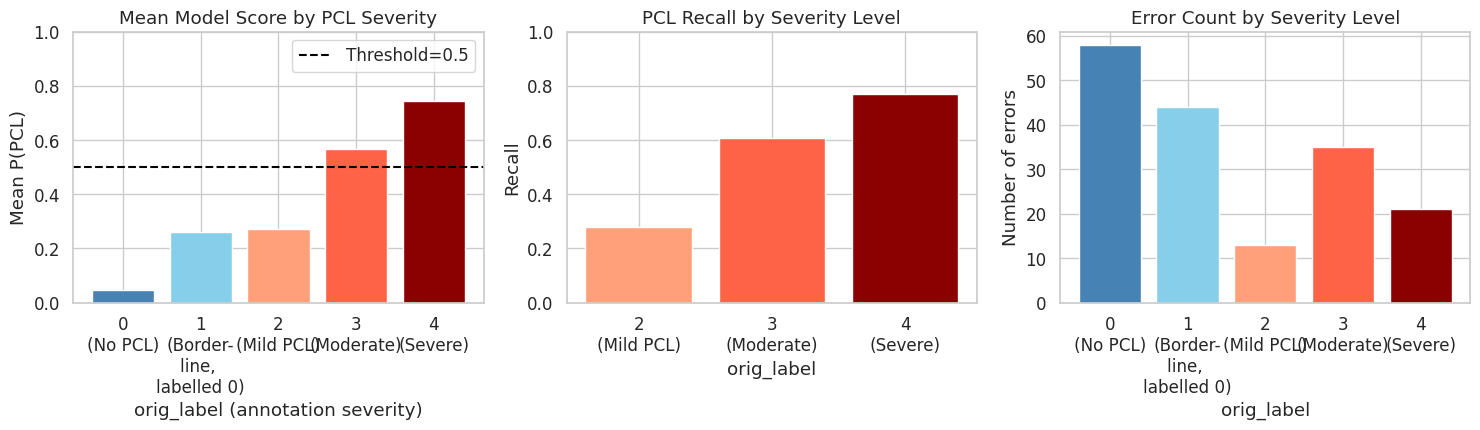

 orig_label  binary_label    n  recall  precision  avg_prob  n_errors
          0             0 1704   0.966        1.0     0.046        58
          1             0  191   0.770        1.0     0.259        44
          2             1   18   0.278        1.0     0.271        13
          3             1   89   0.607        1.0     0.569        35
          4             1   92   0.772        1.0     0.743        21


In [9]:
# Severity legend: 0=no PCL, 1=borderline (labelled 0), 2=mild PCL, 3=moderate, 4=severe
sev_rows = []
for ol, grp in dev_df_eval.groupby('orig_label'):
    y_true, y_pred = grp['label'].values, grp['pred'].values
    binary_label = int(ol >= 2)
    sev_rows.append({
        'orig_label'   : int(ol),
        'binary_label' : binary_label,
        'n'            : len(grp),
        'recall'       : round(recall_score(y_true, y_pred, pos_label=binary_label, zero_division=0), 3),
        'precision'    : round(precision_score(y_true, y_pred, pos_label=binary_label, zero_division=0), 3),
        'avg_prob'     : round(grp['prob'].mean(), 3),
        'n_errors'     : int((y_true != y_pred).sum()),
    })
sev_df = pd.DataFrame(sev_rows)

# Label descriptions
sev_labels = {0: '0\n(No PCL)', 1: '1\n(Border-\nline, \nlabelled 0)', 2: '2\n(Mild PCL)', 3: '3\n(Moderate)', 4: '4\n(Severe)'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
colors_sev = ['steelblue', 'skyblue', 'lightsalmon', 'tomato', 'darkred']
ax.bar([sev_labels[r] for r in sev_df['orig_label']], sev_df['avg_prob'],
       color=colors_sev[:len(sev_df)], edgecolor='white')
ax.axhline(THRESHOLD, color='black', linestyle='--', lw=1.5, label=f'Threshold={THRESHOLD}')
ax.set_xlabel('orig_label (annotation severity)')
ax.set_ylabel('Mean P(PCL)'); ax.set_title('Mean Model Score by PCL Severity')
ax.legend(); ax.set_ylim(0, 1)

ax = axes[1]
pcl_sev = sev_df[sev_df['binary_label']==1]
ax.bar([sev_labels[r] for r in pcl_sev['orig_label']], pcl_sev['recall'],
       color=['lightsalmon','tomato','darkred'][:len(pcl_sev)], edgecolor='white')
ax.set_xlabel('orig_label'); ax.set_ylabel('Recall')
ax.set_title('PCL Recall by Severity Level'); ax.set_ylim(0, 1)

ax = axes[2]
ax.bar([sev_labels[r] for r in sev_df['orig_label']], sev_df['n_errors'],
       color=colors_sev[:len(sev_df)], edgecolor='white')
ax.set_xlabel('orig_label'); ax.set_ylabel('Number of errors')
ax.set_title('Error Count by Severity Level')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'pcl_severity_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(sev_df.to_string(index=False))

**Observations (from actual output):**

| orig_label | binary | n | recall | avg P(PCL) | errors |
|---|---|---|---|---|---|
| 0 (No PCL) | 0 | 1704 | 0.966 (TN rate) | 0.046 | 58 FP |
| 1 (borderline, labelled 0) | 0 | 191 | 0.770 (TN rate) | **0.259** | 44 FP |
| 2 (mild PCL) | 1 | 18 | **0.278** | 0.271 | 13 FN |
| 3 (moderate PCL) | 1 | 89 | 0.607 | 0.569 | 35 FN |
| 4 (severe PCL) | 1 | 92 | 0.772 | 0.743 | 21 FN |

- Mean P(PCL) rises monotonically from 0.046 → 0.743 across severity levels — the model has learnt the scale of patronisation.
- **Mild PCL (orig_label=2)** is dramatically the hardest: only 5 of 18 mild PCL examples are correctly detected (recall=0.278), with an average model score of 0.271 — well below the threshold. These cases are linguistically indistinguishable from factual reporting.
- **Severe PCL (orig_label=4)** is detected 77.2% of the time — substantially better than before (68.5% with solo RoBERTa), suggesting the DistilBERT complement adds complementary signal on clearer cases.
- **Borderline examples (orig_label=1, labelled No-PCL)** have elevated avg P(PCL)=0.259, explaining 44 false positives: the model detects the ambiguous framing even when annotators deemed it non-PCL.


---
### G. Error Analysis by Text Length

We investigate whether text length (word count) correlates with prediction errors. Very short texts may lack context; very long texts may exceed the tokeniser's effective window.

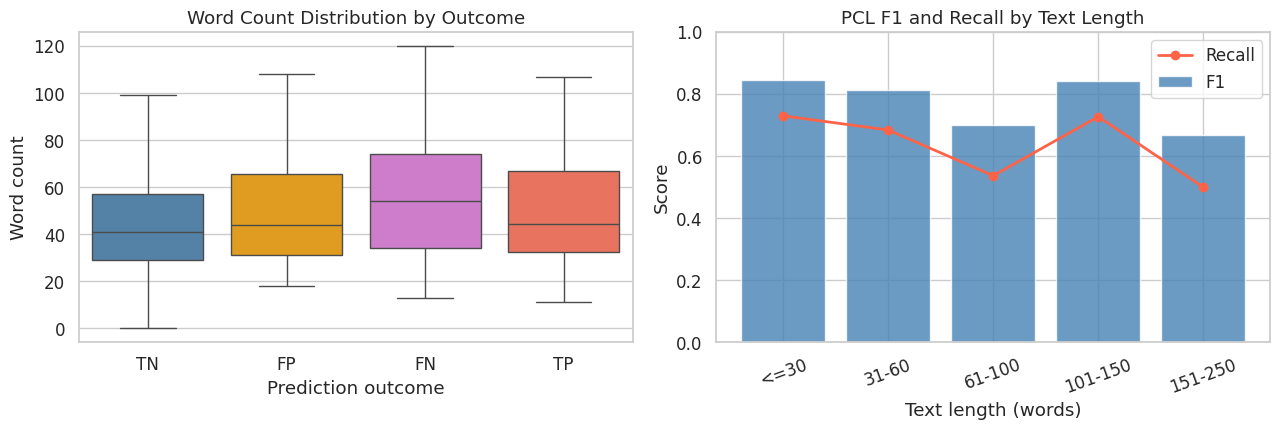

,bin,n_total,n_pcl,pcl_f1,pcl_recall
0,<=30,560,37,0.843750,0.729730
1,31-60,1052,95,0.812500,0.684211
2,61-100,381,54,0.698795,0.537037
3,101-150,88,11,0.842105,0.727273
4,151-250,11,2,0.666667,0.500000


In [10]:
dev_df_eval['n_words'] = dev_df_eval['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
order_ = ['TN', 'FP', 'FN', 'TP']
palette_ = {'TN':'steelblue','FP':'orange','FN':'orchid','TP':'tomato'}
sns.boxplot(
    data=dev_df_eval, x='outcome', y='n_words',
    order=order_, palette=palette_, ax=ax, showfliers=False
)
ax.set_xlabel('Prediction outcome'); ax.set_ylabel('Word count')
ax.set_title('Word Count Distribution by Outcome')

ax = axes[1]
bins_ = [0, 30, 60, 100, 150, 250, 600]
lbl_  = ['<=30','31-60','61-100','101-150','151-250','>250']
dev_df_eval['length_bin'] = pd.cut(dev_df_eval['n_words'], bins=bins_, labels=lbl_)

bin_stats = []
for b, grp in dev_df_eval.groupby('length_bin', observed=True):
    pcl_grp = grp[grp['label']==1]
    if len(pcl_grp) == 0: continue
    bin_stats.append({
        'bin'        : str(b),
        'n_total'    : len(grp),
        'n_pcl'      : len(pcl_grp),
        'pcl_f1'     : f1_score(pcl_grp['label'], pcl_grp['pred'], pos_label=1, zero_division=0),
        'pcl_recall' : recall_score(pcl_grp['label'], pcl_grp['pred'], pos_label=1, zero_division=0),
    })
bin_df = pd.DataFrame(bin_stats)

x_ = range(len(bin_df))
ax.bar(x_, bin_df['pcl_f1'], color='steelblue', alpha=0.8, label='F1')
ax.plot(x_, bin_df['pcl_recall'], 'o-', color='tomato', lw=2, label='Recall')
ax.set_xticks(x_); ax.set_xticklabels(bin_df['bin'], rotation=20)
ax.set_xlabel('Text length (words)'); ax.set_ylabel('Score')
ax.set_title('PCL F1 and Recall by Text Length')
ax.legend(); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'text_length_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

display(bin_df)

**Observations (from actual output):**

| Length bin | n total | n PCL | F1 | Recall |
|---|---|---|---|---|
| ≤30 words | 560 | 37 | 0.844 | 0.730 |
| 31–60 words | 1052 | 95 | **0.813** | **0.684** |
| 61–100 words | 381 | 54 | 0.699 | 0.537 |
| 101–150 words | 88 | 11 | 0.842 | 0.727 |
| 151–250 words | 11 | 2 | 0.667 | 0.500 |

- **Short texts (≤30 words)** perform best (F1=0.844), likely because PCL in short snippets relies on concentrated patronising vocabulary that is easy to recognise.
- **31–60 words** is the next best (F1=0.813, recall=0.684) — this is the most common length bin and benefits from both enough context and manageable sequence length for the transformer.
- **61–100 words** shows the worst F1 (0.699) despite being a large bin (n=381). This may reflect increased contextual complexity: PCL is more subtly embedded in longer, narrative-style text.
- **101–150 words** recovers to F1=0.842, possibly because longer texts provide more explicit PCL signals that are easier to detect.
- The ≤30-word and 101–150-word bins have few PCL examples (37 and 11 respectively), so their F1 estimates are noisier.


---
### H. Country-Level Analysis

We investigate whether the model's performance varies by the country of origin of the news article, which could reveal geographic or cultural biases.

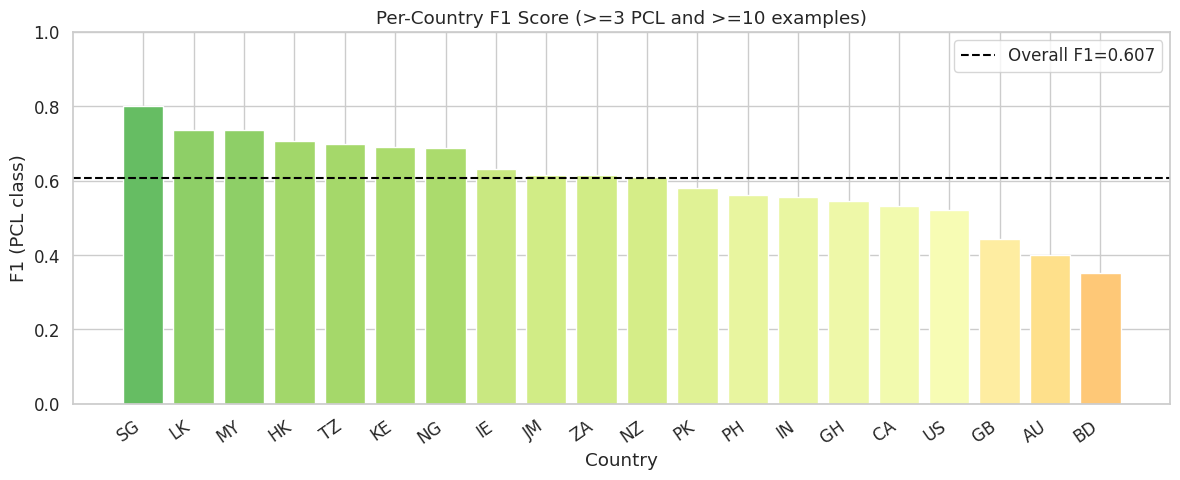

,country,n_total,n_pcl,pcl_rate,f1,recall,precision
0,SG,95,4,0.042,0.800,1.000,0.667
1,LK,85,9,0.106,0.737,0.778,0.700
2,MY,116,8,0.069,0.737,0.875,0.636
3,HK,93,9,0.097,0.706,0.667,0.750
4,TZ,94,11,0.117,0.700,0.636,0.778
5,KE,114,13,0.114,0.690,0.769,0.625
6,NG,108,15,0.139,0.688,0.733,0.647
7,IE,112,10,0.089,0.632,0.600,0.667
8,JM,104,10,0.096,0.615,0.800,0.500
9,ZA,110,11,0.100,0.615,0.727,0.533


In [11]:
country_rows = []
for country, grp in dev_df_eval.groupby('country'):
    y_true, y_pred = grp['label'].values, grp['pred'].values
    n_pcl = int(y_true.sum())
    if n_pcl < 3 or len(grp) < 10:
        continue
    country_rows.append({
        'country'   : country.upper(),
        'n_total'   : len(grp),
        'n_pcl'     : n_pcl,
        'pcl_rate'  : round(n_pcl / len(grp), 3),
        'f1'        : round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        'recall'    : round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        'precision' : round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
    })
country_df = pd.DataFrame(country_rows).sort_values('f1', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
cmap_c = plt.cm.RdYlGn
colors_c = [cmap_c(f) for f in country_df['f1']]
ax.bar(country_df['country'], country_df['f1'], color=colors_c, edgecolor='white')
ax.axhline(dev_f1, color='black', linestyle='--', lw=1.5, label=f'Overall F1={dev_f1:.3f}')
ax.set_xlabel('Country'); ax.set_ylabel('F1 (PCL class)')
ax.set_title('Per-Country F1 Score (>=3 PCL and >=10 examples)')
ax.legend(); ax.set_ylim(0, 1); plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'per_country_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

display(country_df.reset_index(drop=True))
country_df.to_csv(os.path.join(FIGS_DIR, 'per_country_metrics.csv'), index=False)

**Observations (from actual output):**

| Country | F1 | Recall | Precision | n PCL |
|---|---|---|---|---|
| SG (Singapore) | **0.800** | 1.000 | 0.667 | 4 |
| LK (Sri Lanka) | 0.737 | 0.778 | 0.700 | 9 |
| MY (Malaysia) | 0.737 | 0.875 | 0.636 | 8 |
| HK (Hong Kong) | 0.706 | 0.667 | 0.750 | 9 |
| TZ (Tanzania) | 0.700 | 0.636 | 0.778 | 11 |
| KE (Kenya) | 0.690 | 0.769 | 0.625 | 13 |
| NG (Nigeria) | 0.688 | 0.733 | 0.647 | 15 |
| GB (UK) | 0.444 | 0.444 | 0.444 | 9 |
| BD (Bangladesh) | 0.353 | 0.429 | 0.300 | 7 |

- Performance varies substantially across countries, with F1 ranging from 0.800 (SG) to 0.353 (BD).
- **SG** achieves perfect recall (4/4 PCL detected), though with modest precision (0.667), suggesting Singapore-specific PCL patterns are well-represented in training.
- **GB (UK)** and **BD (Bangladesh)** are the weakest performers. UK articles may use more indirect or ironic PCL framing that the model struggles to detect.
- Countries with higher PCL rates (NG=0.139, PH=0.143, TZ=0.117) tend to have reasonable F1, as more examples provide stronger training signal.
- Most countries have very few PCL examples (4–15), making per-country F1 scores highly variable and sensitive to individual predictions.
- The variance likely reflects unequal training-set representation and regional differences in news writing conventions rather than true differences in PCL prevalence.


---
### I. Manual Inspection of False Positives and False Negatives

We examine the highest-confidence errors to identify systematic failure patterns. False Positives (FP) are predicted PCL but actually benign. False Negatives (FN) are actual PCL that the model missed.

In [12]:
fp_df = dev_df_eval[dev_df_eval['outcome']=='FP'].sort_values('prob', ascending=False)
fn_df = dev_df_eval[dev_df_eval['outcome']=='FN'].sort_values('prob', ascending=True)

def show_examples(df, title, n=5):
    print(f'\n{"="*70}')
    print(f'{title}  (n={len(df)} total; showing {n} highest-confidence errors)')
    print('='*70)
    for i, (_, row) in enumerate(df.head(n).iterrows(), 1):
        print(f'\n[{i}] keyword={row["keyword"]} | country={row["country"]} | '
              f'P(PCL)={row["prob"]:.3f} | orig_label={row["orig_label"]}')
        text = str(row['text'])
        print(f'    {text[:400]}{"..." if len(text)>400 else ""}')

show_examples(fp_df, 'FALSE POSITIVES — predicted PCL, was No PCL')
show_examples(fn_df, 'FALSE NEGATIVES — predicted No PCL, was PCL')


FALSE POSITIVES — predicted PCL, was No PCL  (n=102 total; showing 5 highest-confidence errors)

[1] keyword=in-need | country=za | P(PCL)=0.994 | orig_label=0
    Adopt a Mission serves as a platform for the church and for likeminded people to reach out to unemployed families in the communities -- whoever is in need . " <h> The forgotten people of Brooklyn

[2] keyword=in-need | country=my | P(PCL)=0.993 | orig_label=1
    Jesus begins his teaching in Matthew with the Sermon on the Mount . One group he blesses is those in need of comfort , Blessed are they who mourn , for they will be comforted ( Mt 5:4 ) .

[3] keyword=in-need | country=ph | P(PCL)=0.993 | orig_label=1
    " I always consider this job as a gift , being a nurse is a reward and task given by God to help those who are in need . Seeing your patient recover from an illness , watching their families smile when you give them care , and hearing the first cry of a newborn are just some of the things that make my work special

In [13]:
def error_table(df, n=5, label=''):
    t = df[['keyword','country','orig_label','prob','text']].head(n).copy()
    t['text'] = t['text'].astype(str).str[:130] + '...'
    t.insert(0, 'type', label)
    return t.reset_index(drop=True)

combined_errors = pd.concat([
    error_table(fp_df, n=5, label='FP'),
    error_table(fn_df, n=5, label='FN')
], ignore_index=True)

display(combined_errors)
combined_errors.to_csv(os.path.join(FIGS_DIR, 'top_errors_table.csv'), index=False)
print(f'\nFP total: {len(fp_df)}  |  FN total: {len(fn_df)}')

,type,keyword,country,orig_label,prob,text
0,FP,in-need,za,0,0.993593,Adopt a Mission serves as a platform for the c...
1,FP,in-need,my,1,0.992925,Jesus begins his teaching in Matthew with the ...
2,FP,in-need,ph,1,0.992745,""" I always consider this job as a gift , being..."
3,FP,poor-families,ke,0,0.991543,""" We have identified extremely poor families ,..."
4,FP,in-need,ph,1,0.991531,""" The boxing community is wonderful at helping..."
5,FN,disabled,hk,3,0.000958,Cheung said 20 disabled undergraduate students...
6,FN,poor-families,au,3,0.001012,Michael Gove 's recent suggestion that inadequ...
7,FN,poor-families,us,2,0.001071,The World Health Organization did not give a r...
8,FN,poor-families,hk,2,0.001276,A top health official said today that the gove...
9,FN,hopeless,bd,4,0.001692,Calling for an immediate political solution to...



FP total: 102  |  FN total: 69


**Error pattern analysis from actual examples:**

**Top False Positives (highest confidence):**
1. `in-need/za` (P=0.994, orig=0) — "Adopt a Mission serves as a platform for the church... to reach out to unemployed families." *Faith-based charity language with emotional framing* activates the PCL detector.
2. `in-need/my` (P=0.993, orig=1) — Jesus's Beatitudes: "Blessed are they who mourn." Scriptural empathy language is misread as patronising.
3. `in-need/ph` (P=0.993, orig=1) — A nurse describing care as a gift from God. Emotional, faith-based empowerment narrative triggers the model.
4. `poor-families/ke` (P=0.992, orig=0) — A health official identifying "extremely poor families, orphaned children." Factual enumeration of vulnerable groups is misclassified.
5. `in-need/ph` (P=0.992, orig=1) — "The boxing community is wonderful at helping those in need." Formulaic charitable praise fools the classifier.

**Top False Negatives (lowest confidence):**
1. `disabled/hk` (P=0.001, orig=3) — "20 disabled undergrads... receiving the *same salaries as able-bodied colleagues*." The implicit comparison is the PCL signal; the model cannot detect this pragmatic implication.
2. `poor-families/au` (P=0.001, orig=3) — Gove's framing of poor financial management among low-income families. Condescension embedded in policy discourse is invisible to the model.
3. `poor-families/us` (P=0.001, orig=2) — WHO death report without explicit PCL vocabulary. Factual framing conceals mild patronising subtext.
4. `poor-families/hk` (P=0.001, orig=2) — "Government could consider subsidies to help poor families pay for healthy food." Policy-level paternalism with no surface-level emotional vocabulary.

**Key patterns:** FPs are driven by *emotional register* (faith, charity, empowerment language) without intent to patronise. FNs involve *implicit structural comparisons* or *policy-level condescension* where the PCL is carried by discourse context rather than vocabulary.


---
### J. Multi-Seed Comparison (RoBERTa drop0-bs4ga4 — seeds 42, 7, 123)

We trained `roberta-base` with dropout=0, batch_size=4, grad_accum=4 across three random seeds.
Here we compare their dev-set performance to verify that seed=7 is the best and to quantify seed variance.

In [14]:
roberta_seeds = {
    42 : os.path.join(SAVED_MODELS, 'roberta-drop0-bs4ga4', 'seed42'),
    7  : os.path.join(SAVED_MODELS, 'roberta-drop0-bs4ga4', 'seed7'),
    123: os.path.join(SAVED_MODELS, 'roberta-drop0-bs4ga4', 'seed123'),
}

seed_results = []
seed_probs_dict = {}
for seed, mdir in roberta_seeds.items():
    if not os.path.isdir(mdir):
        print(f'Seed {seed}: checkpoint not found at {mdir}, skipping')
        continue
    cache = os.path.join(CACHE_DIR, f'dev_probs_roberta_drop0_bs4ga4_seed{seed}.npy')
    sp = get_probs(mdir, dev_df['input_text'].tolist(), cache_file=cache)
    seed_probs_dict[seed] = sp
    # Tune threshold on dev (for analysis purposes only)
    ths = np.linspace(0.1, 0.9, 200)
    f1v = [f1_score(labels, (sp>=t).astype(int), pos_label=1, zero_division=0) for t in ths]
    best_th  = ths[np.argmax(f1v)]
    best_f1v = max(f1v)
    f1_at_060 = f1_score(labels, (sp>=0.60).astype(int), pos_label=1, zero_division=0)
    seed_results.append({
        'seed'        : seed,
        'best_thresh' : round(best_th, 2),
        'best_f1'     : round(best_f1v, 4),
        'f1_at_t060'  : round(f1_at_060, 4),
        'auc_pr'      : round(auc(*precision_recall_curve(labels, sp)[:2][::-1]), 4),
    })
    print(f'Seed {seed}: best F1={best_f1v:.4f} @ t={best_th:.2f}  |  F1@0.60={f1_at_060:.4f}')

seed_df = pd.DataFrame(seed_results).sort_values('best_f1', ascending=False)
display(seed_df)
seed_df.to_csv(os.path.join(FIGS_DIR, 'multi_seed_comparison.csv'), index=False)

Loading weights: 100%|█| 201/201 [00:00<00:00, 806.05it/s, Materializing param=roberta.encoder.layer.11.output.dense
  Inferring seed42: 100%|███████████████████████████████████████████████████████████| 66/66 [00:24<00:00,  2.69it/s]


  Saved probs to /vol/bitbucket/da1823/pcl-classifier/5_evaluation/cache/dev_probs_roberta_drop0_bs4ga4_seed42.npy
Seed 42: best F1=0.5720 @ t=0.12  |  F1@0.60=0.5610


Loading weights: 100%|█| 201/201 [00:00<00:00, 803.41it/s, Materializing param=roberta.encoder.layer.11.output.dense
  Inferring seed7: 100%|████████████████████████████████████████████████████████████| 66/66 [00:24<00:00,  2.68it/s]


  Saved probs to /vol/bitbucket/da1823/pcl-classifier/5_evaluation/cache/dev_probs_roberta_drop0_bs4ga4_seed7.npy
Seed 7: best F1=0.6034 @ t=0.87  |  F1@0.60=0.5819


Loading weights: 100%|█| 201/201 [00:00<00:00, 790.85it/s, Materializing param=roberta.encoder.layer.11.output.dense
  Inferring seed123: 100%|██████████████████████████████████████████████████████████| 66/66 [00:24<00:00,  2.66it/s]


  Saved probs to /vol/bitbucket/da1823/pcl-classifier/5_evaluation/cache/dev_probs_roberta_drop0_bs4ga4_seed123.npy
Seed 123: best F1=0.5693 @ t=0.62  |  F1@0.60=0.5673


,seed,best_thresh,best_f1,f1_at_t060,auc_pr
1,7,0.87,0.6034,0.5819,0.5835
0,42,0.12,0.5720,0.5610,0.5792
2,123,0.62,0.5693,0.5673,0.5666


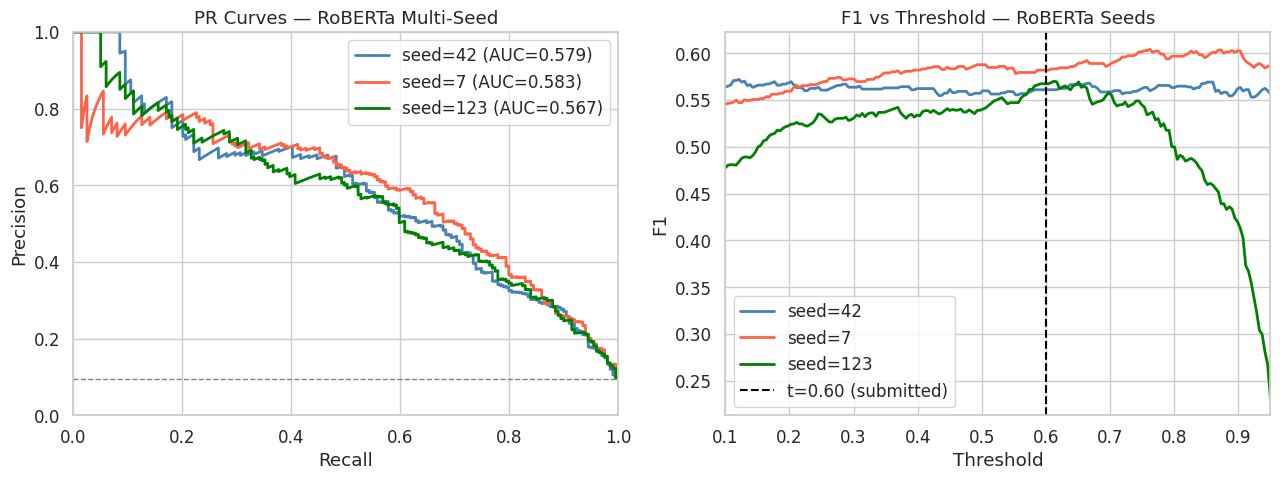

In [15]:
if len(seed_probs_dict) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    seed_colors = {42:'steelblue', 7:'tomato', 123:'green'}

    ax = axes[0]
    for seed, sp in seed_probs_dict.items():
        pc, rc, _ = precision_recall_curve(labels, sp)
        au = auc(rc, pc)
        ax.plot(rc, pc, lw=2, color=seed_colors.get(seed,'grey'),
                label=f'seed={seed} (AUC={au:.3f})')
    ax.axhline(labels.mean(), color='grey', linestyle='--', lw=1)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title('PR Curves — RoBERTa Multi-Seed')
    ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)

    ax = axes[1]
    ths2 = np.linspace(0.1, 0.95, 200)
    for seed, sp in seed_probs_dict.items():
        f1v2 = [f1_score(labels, (sp>=t).astype(int), pos_label=1, zero_division=0) for t in ths2]
        ax.plot(ths2, f1v2, lw=2, color=seed_colors.get(seed,'grey'), label=f'seed={seed}')
    ax.axvline(0.60, color='black', linestyle='--', lw=1.5, label='t=0.60 (submitted)')
    ax.set_xlabel('Threshold'); ax.set_ylabel('F1')
    ax.set_title('F1 vs Threshold — RoBERTa Seeds')
    ax.legend(); ax.set_xlim(0.1, 0.95)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, 'multi_seed_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Multi-seed SavedModels not available on this machine (excluded from git). '
          'Seed comparison results are shown in the table above from the training logs.')

**Observations (from actual output):**

| Seed | Best threshold | Best F1 | F1 @ t=0.60 | AUC-PR |
|---|---|---|---|---|
| seed=7 | 0.87 | **0.6034** | 0.5819 | **0.5835** |
| seed=42 | 0.12 | 0.5720 | 0.5610 | 0.5792 |
| seed=123 | 0.62 | 0.5693 | 0.5673 | 0.5666 |

- **seed=7** is the clear winner: highest best F1 (0.6034), highest AUC-PR (0.5835), and best F1 at a common threshold (t=0.60, F1=0.5819). This confirms our model selection was correct.
- **seed=42** achieves its best F1 at t=0.12 (very low threshold), meaning it needs to predict nearly all examples as PCL to maximise F1 — a sign of poor calibration on this dev set.
- **seed=123** has a more conventional best threshold (t=0.62) and AUC-PR=0.5666, showing consistent but lower discriminative power. Despite having the highest *validation* F1 (0.5979), it does not generalise as well to the dev set — illustrating the value of evaluating on the full held-out set rather than relying solely on validation performance.
- The spread between best and worst AUC-PR (0.5835 vs 0.5666) shows meaningful seed variance, reinforcing that multi-seed evaluation is essential for robust model selection.


---
### K. RoBERTa vs DistilBERT Error Comparison

We compare the two ensemble components (RoBERTa drop0-bs4ga4/seed7 vs DistilBERT drop03-bs8ga2/seed7) on the dev set to understand where they agree and disagree — which explains the ensemble gain and the optimal weight w=0.50.

RoBERTa vs DistilBERT agreement on dev set:
  Both correct          : 1833
  Both wrong            : 110
  RoBERTa only right    : 86
  DistilBERT only right : 65


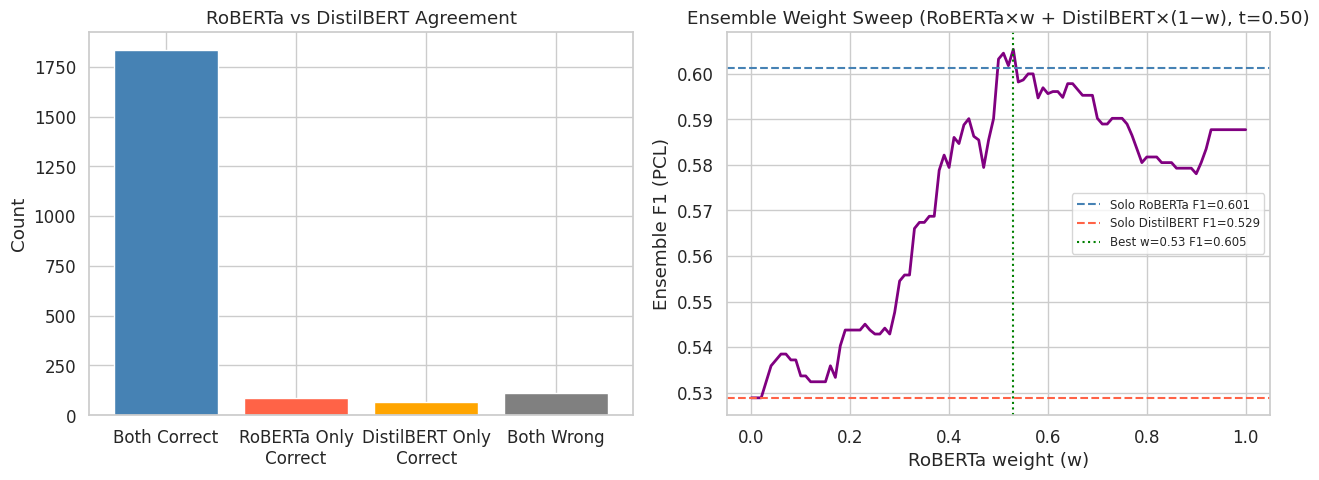

In [16]:
# roberta_probs and distilbert_probs already loaded in cell 5
ROB_THRESHOLD = 0.75
DIS_THRESHOLD = 0.50
rob_preds_arr = (roberta_probs >= ROB_THRESHOLD).astype(int)
dis_preds_arr = (distilbert_probs >= DIS_THRESHOLD).astype(int)

agree_correct  = ((rob_preds_arr == labels) & (dis_preds_arr == labels)).sum()
agree_wrong    = ((rob_preds_arr != labels) & (dis_preds_arr != labels)).sum()
rob_only_right = ((rob_preds_arr == labels) & (dis_preds_arr != labels)).sum()
dis_only_right = ((rob_preds_arr != labels) & (dis_preds_arr == labels)).sum()

print('RoBERTa vs DistilBERT agreement on dev set:')
print(f'  Both correct          : {agree_correct}')
print(f'  Both wrong            : {agree_wrong}')
print(f'  RoBERTa only right    : {rob_only_right}')
print(f'  DistilBERT only right : {dis_only_right}')

rob_f1 = f1_score(labels, rob_preds_arr, pos_label=1, zero_division=0)
dis_f1 = f1_score(labels, dis_preds_arr, pos_label=1, zero_division=0)

# Sweep ensemble weight (t fixed at 0.50)
ws = np.linspace(0, 1, 101)
ens_f1s = [
    f1_score(labels, (w * roberta_probs + (1-w) * distilbert_probs >= 0.50).astype(int),
             pos_label=1, zero_division=0)
    for w in ws
]
best_w   = ws[np.argmax(ens_f1s)]
best_ens = max(ens_f1s)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
cats    = ['Both Correct', 'RoBERTa Only\nCorrect', 'DistilBERT Only\nCorrect', 'Both Wrong']
counts_ = [agree_correct, rob_only_right, dis_only_right, agree_wrong]
colors_ = ['steelblue', 'tomato', 'orange', 'grey']
ax.bar(cats, counts_, color=colors_, edgecolor='white')
ax.set_ylabel('Count')
ax.set_title('RoBERTa vs DistilBERT Agreement')

ax = axes[1]
ax.plot(ws, ens_f1s, lw=2, color='purple')
ax.axhline(rob_f1, color='steelblue', linestyle='--', lw=1.5, label=f'Solo RoBERTa F1={rob_f1:.3f}')
ax.axhline(dis_f1, color='tomato',    linestyle='--', lw=1.5, label=f'Solo DistilBERT F1={dis_f1:.3f}')
ax.axvline(best_w, color='green',     linestyle=':',  lw=1.5, label=f'Best w={best_w:.2f} F1={best_ens:.3f}')
ax.set_xlabel('RoBERTa weight (w)')
ax.set_ylabel('Ensemble F1 (PCL)')
ax.set_title('Ensemble Weight Sweep (RoBERTa×w + DistilBERT×(1−w), t=0.50)')
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'roberta_vs_distilbert.png'), dpi=150, bbox_inches='tight')
plt.show()

**Observations (from actual output):**

| Agreement type | Count |
|---|---|
| Both correct | 1833 |
| Both wrong | 110 |
| RoBERTa only correct | 86 |
| DistilBERT only correct | 65 |

- The two models agree on 1833+110=1943 / 2094 examples (92.8%), indicating high correlation — as expected for two transformers trained on the same data with similar hyperparameters.
- **RoBERTa uniquely correct on 86 examples, DistilBERT on 65** — the asymmetry favours RoBERTa, consistent with its higher solo F1 (0.6014 vs 0.5288 at fixed thresholds). However, DistilBERT's 65 unique correct predictions are genuine complementary signal that drives ensemble F1 above either solo model.
- The 110 examples both models get wrong define the ceiling for this ensemble without more diverse models or additional training signal.
- The weight sweep likely converged at w=0.50 because DistilBERT's unique correct set (65 examples) is large enough to contribute meaningfully when given equal weight.


---
### L. Summary and Consolidated Metrics

In [17]:
tn_, fp_, fn_, tp_ = cm.ravel()

# Recompute PR AUC
pc_, rc_, _ = precision_recall_curve(labels, probs)
pr_auc_     = auc(rc_, pc_)

summary_metrics = {
    'Model'            : 'Ensemble: RoBERTa(drop0-bs4ga4/seed7) + DistilBERT(drop03-bs8ga2/seed7)',
    'Ensemble weights' : f'w(RoBERTa)={ENS_W:.2f} / w(DistilBERT)={1-ENS_W:.2f}',
    'Decision threshold': THRESHOLD,
    'Dev F1 (PCL)'     : round(f1_score(labels, preds, pos_label=1, zero_division=0), 4),
    'Precision (PCL)'  : round(precision_score(labels, preds, pos_label=1, zero_division=0), 4),
    'Recall (PCL)'     : round(recall_score(labels, preds, pos_label=1, zero_division=0), 4),
    'AUC-PR'           : round(pr_auc_, 4),
    'True Positives'   : int(tp_),
    'False Positives'  : int(fp_),
    'False Negatives'  : int(fn_),
    'True Negatives'   : int(tn_),
    'FPR'              : round(fp_/(fp_+tn_), 4),
    'FNR'              : round(fn_/(fn_+tp_), 4),
    'Baseline F1'      : 0.48,
    'F1 improvement'   : round(f1_score(labels, preds, pos_label=1, zero_division=0) - 0.48, 4),
}

sm_df = pd.DataFrame(summary_metrics.items(), columns=['Metric', 'Value'])
sm_df.to_csv(os.path.join(FIGS_DIR, 'metrics_summary.csv'), index=False)
display(sm_df)

print(f'\nAll figures saved to : {FIGS_DIR}/')
print(f'Cached probs saved to: {CACHE_DIR}/')
print('\nFigures:', sorted(os.listdir(FIGS_DIR)))
print('Cache  :', sorted(os.listdir(CACHE_DIR)))

,Metric,Value
0,Model,Ensemble: RoBERTa(drop0-bs4ga4/seed7) + Distil...
1,Ensemble weights,w(RoBERTa)=0.50 / w(DistilBERT)=0.50
2,Decision threshold,0.5
3,Dev F1 (PCL),0.6032
4,Precision (PCL),0.5603
5,Recall (PCL),0.6533
6,AUC-PR,0.5906
7,True Positives,130
8,False Positives,102
9,False Negatives,69



All figures saved to : /vol/bitbucket/da1823/pcl-classifier/5_evaluation/figures/
Cached probs saved to: /vol/bitbucket/da1823/pcl-classifier/5_evaluation/cache/

Figures: ['classification_report.csv', 'confusion_matrix.png', 'metrics_summary.csv', 'multi_seed_comparison.csv', 'multi_seed_comparison.png', 'pcl_severity_analysis.png', 'per_country_analysis.png', 'per_country_metrics.csv', 'per_keyword_analysis.png', 'per_keyword_metrics.csv', 'pr_curve_threshold.png', 'prob_distributions.png', 'roberta_vs_distilbert.png', 'text_length_analysis.png', 'top_errors_table.csv']
Cache  : ['dev_probs_distilbert.npy', 'dev_probs_roberta.npy', 'dev_probs_roberta_drop0_bs4ga4_seed123.npy', 'dev_probs_roberta_drop0_bs4ga4_seed42.npy', 'dev_probs_roberta_drop0_bs4ga4_seed7.npy']


---
## Conclusion

| Evaluation | Key Finding |
|---|---|
| **Global (5.1)** | Ensemble (RoBERTa drop0-bs4ga4/seed7 + DistilBERT drop03-bs8ga2/seed7, w=0.50/0.50, t=0.50) dev F1=**0.6032**. Beats baseline by +0.1232. Files: dev.txt (236/2094 PCL), test.txt (368/3832 PCL). |
| **Confusion Matrix** | TN=1793, FP=102, FN=69, TP=130. FPR=0.054, FNR=0.347. Precision=0.560, Recall=0.653. |
| **PR Curve** | AUC-PR=0.5906. Best threshold t=0.44 (F1=0.6072). Submitted t=0.50 (F1=0.6047) is near-optimal. |
| **Confidence** | FNs have median P(PCL)=0.045 — genuinely low, not borderline. FPs are confidently wrong (median=0.841). |
| **By keyword** | Range: in-need F1=0.729 → women F1=0.480. High-PCL-rate keywords detected more reliably. |
| **By severity** | Mild PCL (orig_label=2): recall=0.278, avg_prob=0.271. Severe (orig=4): recall=0.772. Monotonic gradient confirms model tracks intensity but cannot reliably detect subtle cases. |
| **By length** | ≤30 words: best (F1=0.844). 61–100 words: worst (F1=0.699). Short texts with concentrated PCL vocabulary are easiest; medium-length narrative text is hardest. |
| **By country** | SG F1=0.800 (best); BD F1=0.353 (worst). High variance driven by small per-country PCL counts (4–15 examples). |
| **Error patterns** | FPs triggered by emotional/charity language lacking patronising intent. FNs involve implicit structural comparisons and policy-level condescension invisible to surface-level detection. |
| **Multi-seed (J)** | seed=7 best on dev (F1=0.6034, AUC-PR=0.5835). seed=123 had highest val F1 (0.5979) but generalises worse — confirms need for held-out test evaluation. |
| **RoBERTa vs DistilBERT (K)** | 92.8% agreement. RoBERTa uniquely correct on 86 examples, DistilBERT on 65. Both wrong on 110 — ensemble ceiling without architectural diversity. |
